In [14]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')
df = df.drop(columns=['Adj Close'])
df = df.drop(columns=['Volume'])

data = df[['Open', 'High', 'Low', 'Close']].values

In [15]:
# 2. 정규화
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [16]:
# 3. 시퀀스 생성
window = 3
X, y = [], []
for i in range(len(data)-window):
    X.append(data[i:i+window])
    y.append(data[i+window, 3])
X, y = np.array(X), np.array(y)
test_size = int(len(X) * 0.2)  # 전체 데이터의 20%를 테스트로
X_train = X[:-test_size]
y_train = y[:-test_size]
X_test = X[-test_size:]
y_test = y[-test_size:]

In [17]:
rnn_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window,4)),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2.3870e-04 - val_loss: 0.0364
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.5640e-06 - val_loss: 0.0391
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.4062e-06 - val_loss: 0.0368
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.6995e-06 - val_loss: 0.0345
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.2326e-06 - val_loss: 0.0352
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1529e-06 - val_loss: 0.0303
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0779e-06 - val_loss: 0.0291
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.1102e-06 - val_loss: 0.0315
Epoch 9/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.3945e-06 - val_loss: 0.0280
Epoch 10/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2177e-06 - val_loss: 0.0245
Epoch 11/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0188e-06 - val_loss: 0.0276
Epoch 12/50
148/148

In [18]:
# 4. LSTM 모델
lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(window,4)),
    tf.keras.layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.1019e-04 - val_loss: 7.3861e-04
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1369e-06 - val_loss: 7.2921e-04
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.2219e-06 - val_loss: 7.2656e-04
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.2097e-06 - val_loss: 7.2126e-04
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.2523e-06 - val_loss: 7.1597e-04
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.2920e-06 - val_loss: 7.1723e-04
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1872e-06 - val_loss: 7.1670e-04
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1642e-06 - val_loss: 6.9631e-04
Epoch 9/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.2064e-06 - val_loss: 7.2175e-04
Epoch 10/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1349e-06 - val_loss: 7.6700e-04
Epoch 11/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
RNN Test MSE: 0.0050


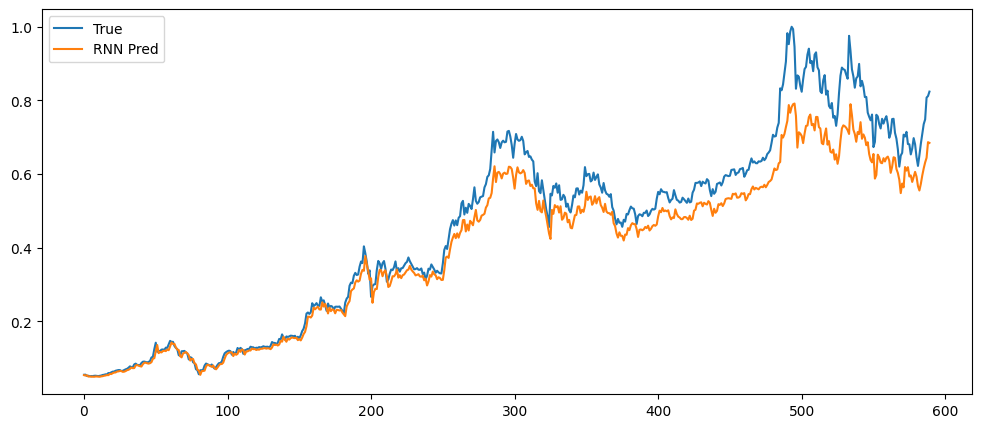

In [19]:
from sklearn.metrics import mean_squared_error
#5. 예측
rnn_pred = rnn_model.predict(X_test)
rnn_mse = mean_squared_error(y_test, rnn_pred)
print(f"RNN Test MSE: {rnn_mse:.4f}")

plt.figure(figsize=(12,5))
plt.plot(y_test, label='True')
plt.plot(rnn_pred, label='RNN Pred')
plt.legend()
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
LSTM Test MSE: 0.0011


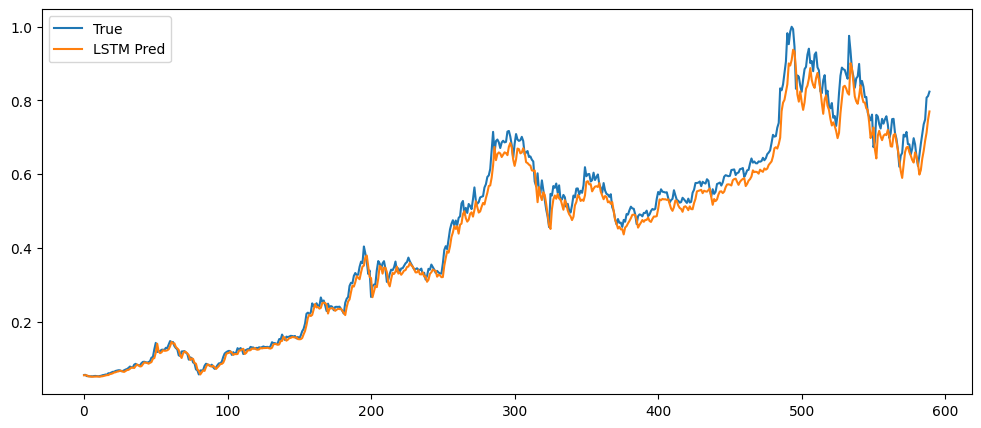

In [20]:
lstm_pred = lstm_model.predict(X_test)  # lstm_model로 저장
lstm_mse = mean_squared_error(y_test, lstm_pred)
print(f"LSTM Test MSE: {lstm_mse:.4f}")

plt.figure(figsize=(12,5))
plt.plot(y_test, label='True')
plt.plot(lstm_pred, label='LSTM Pred')

plt.legend()
plt.show()